In [ ]:
!pip install -q  langchain-openai==0.1.8 langchain_community==0.2.4 tiktoken==0.7.0 langchain==0.2.3
!pip install -q  faiss-cpu==1.8.0 wikipedia==1.4.0 arxiv==2.1.0


In [ ]:
from google.colab import userdata
openai_api_key = userdata.get('openai_api_key')


In [ ]:

from langchain_openai  import ChatOpenAI
from langchain.schema import SystemMessage, HumanMessage,AIMessage, StrOutputParser
from langchain.prompts import PromptTemplate, ChatPromptTemplate, MessagesPlaceholder
llm = ChatOpenAI(openai_api_key=openai_api_key, model='gpt-4-1106-preview', temperature=0)



In [ ]:
prompt = ChatPromptTemplate.from_messages(
  [
    (
      "system", "You are a helpful assistant",
    ),
    ("user", "{text}"),
  ]
)

In [ ]:
prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful assistant",
        ),
        MessagesPlaceholder(variable_name="chat_history"),
        ("user", "{text}"),
    ]
)


In [ ]:
chain = prompt | llm | StrOutputParser()

In [ ]:
chat_history = []



In [ ]:
i = -1

texts = ["I am an LLM specialist who is an expert in LangChain",
         "What is my area of expertise?",
         """Please provide some questions that the LLM (Language Model) may not be proficient at answering,
          but Wikipedia would be well-suited to address."""
         ,""""Who won the Asian National Cup in 2023?""",
         " i want o record a 80 second video to introduce my courese about LangChain. and its application, why we should learn it? why its important to learn? who should learn it?"
         , "No. my friend Langchain is a framework to work with llm. it s not about blockchain or etc. rewrite your previouse answer",
         'you did well. but consider absolutly beginner  and start with some bassic information maybe they do not know llms but they know chatgpt. so use this fact and change: also consider langchain is  a framework to work with llm',
         "can i mention a search engine in langchain application?"]

text = texts[i]
# chat_history = chat_history[-3:]
response_message = chain.invoke({'chat_history':chat_history, 'text':text})
response_message


In [ ]:
chat_history.extend([HumanMessage(content=text), AIMessage(content=response_message)])
chat_history

In [ ]:
prompt.format(text=texts[1], chat_history=chat_history)

In [ ]:
texts[1]

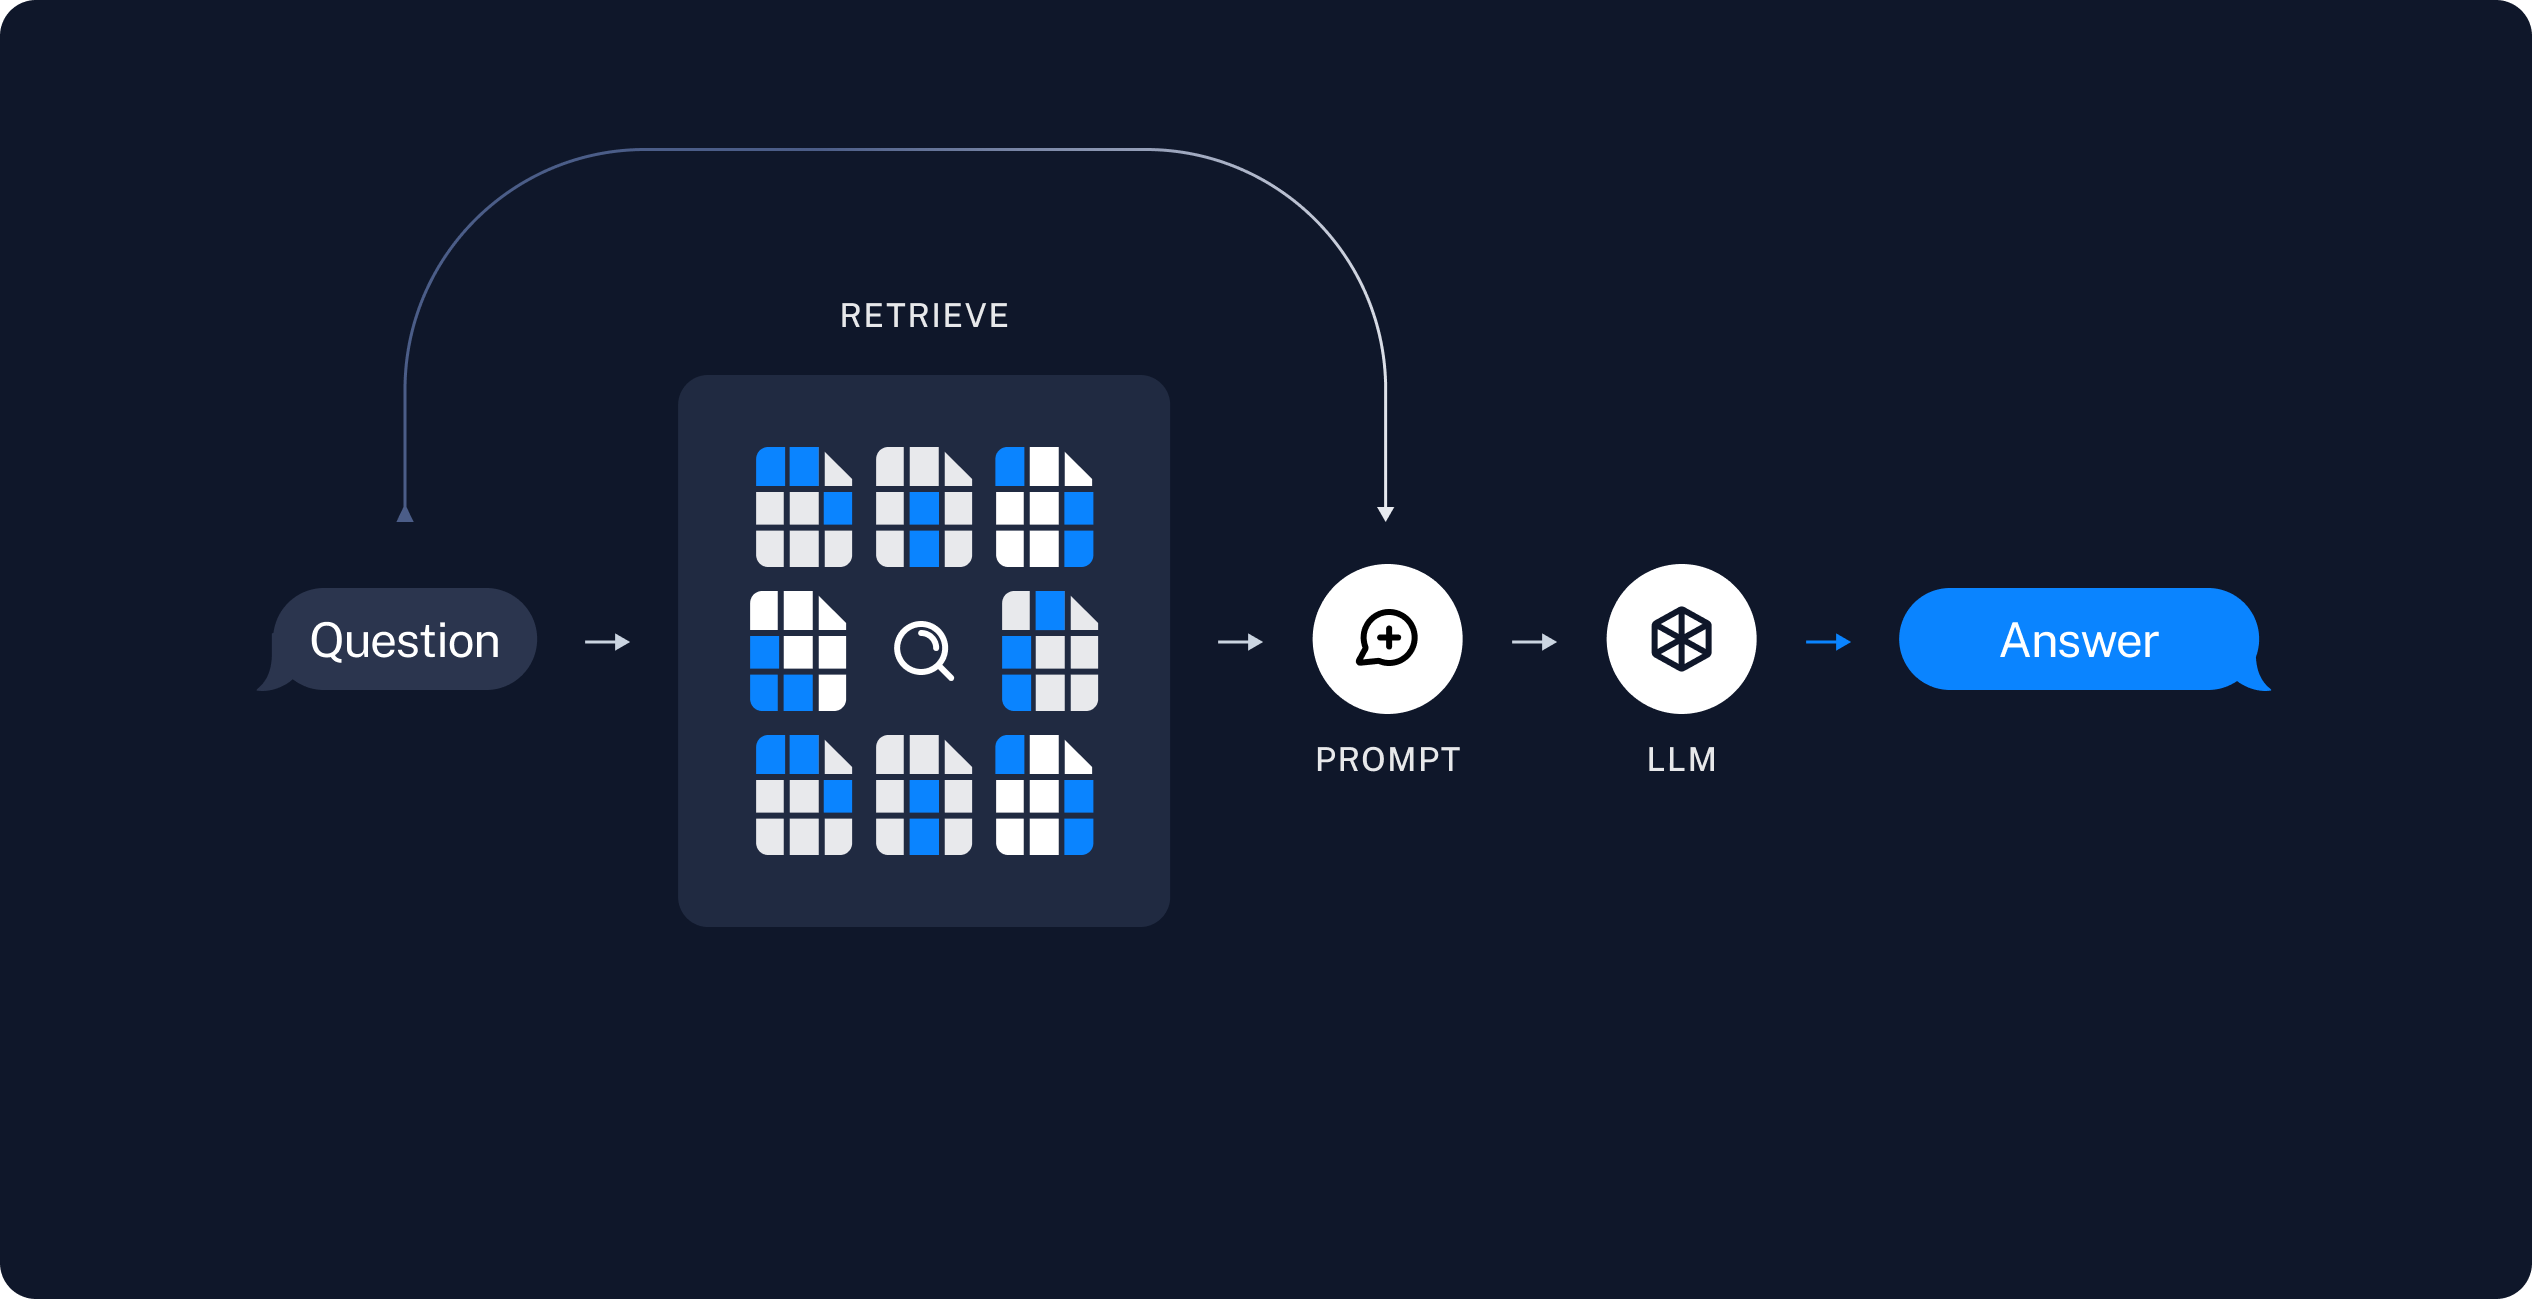

In [ ]:
from langchain.retrievers import WikipediaRetriever
from langchain.retrievers import ArxivRetriever

In [ ]:
retriever = WikipediaRetriever(load_max_docs=1)
# retriever = ArxivRetriever(load_max_docs=2)

In [ ]:
text = texts[3]
text

In [ ]:
llm.invoke([HumanMessage(text)])

In [ ]:
# docs = retriever.get_relevant_documents(query='attention is all you need')
docs = retriever.get_relevant_documents(query='Who won the Asian National Cup in 2023?')




In [ ]:
docs

In [ ]:
from langchain.chains import ConversationalRetrievalChain
from langchain_openai import ChatOpenAI


qa = ConversationalRetrievalChain.from_llm(llm, retriever=retriever)

In [ ]:
qa.invoke({'question': 'Who won the Asian National Cup in 2023?', 'chat_history':[]})

In [ ]:
from langchain.document_loaders import AsyncHtmlLoader
import pandas as pd
df = pd.read_excel('/content/urls.xlsx')
urls = df['url'].values.tolist()
urls[:5]

In [ ]:
loader = AsyncHtmlLoader(urls[:5])
docs = loader.load()

In [ ]:
docs[0]

In [ ]:
from langchain_community.document_transformers import BeautifulSoupTransformer
tags = ["p", "li", 'div']
html = docs[0].page_content
bs_transformer = BeautifulSoupTransformer()
docs_transformed = bs_transformer.transform_documents(
    docs, tags_to_extract=tags
)

In [ ]:
docs_transformed[0]

In [ ]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
text_splitter = RecursiveCharacterTextSplitter(chunk_size=2000, chunk_overlap=20)

text_chunks = text_splitter.split_documents(docs_transformed)



In [ ]:
len(text_chunks)

In [ ]:

from langchain_openai import OpenAIEmbeddings
embedding = OpenAIEmbeddings(openai_api_key=openai_api_key)


In [ ]:

from langchain.vectorstores import FAISS
vs = FAISS.from_documents(text_chunks, embedding)


In [ ]:
# vs.save_local('/content/drive/MyDrive/plantix/plantix_faiss')

In [ ]:
vs = FAISS.load_local('/content/drive/MyDrive/plantix/plantix_faiss', embedding)
vs.similarity_search('aster yellows phytoplasma', k=3)

In [ ]:

def _create_chain(prompt, llm, db):
  chain = (RunnableParallel(
    {"context": itemgetter("question") | db.as_retriever(search_kwargs={"k": 3}), 'question': RunnablePassthrough()}
    ) | prompt | llm)
  return chain

In [ ]:
from langchain_core.runnables import RunnableParallel, RunnablePassthrough
from operator import itemgetter

In [ ]:
prompt = ChatPromptTemplate.from_messages([
  ('system', "You are a helpful assistant please answer based on your {context}"),
  ('user', '{question}')

])
chain = _create_chain(prompt, llm, vs)

In [ ]:
j = 1
queries = [
    "What is the primary cause of aster yellows-phytoplasma in plants?",
    'Which plants are commonly affected by aster yellows phytoplasma?',
    'How does aster yellows-phytoplasma spread from plant to plant?',
    'Are there any specific symptoms or signs that indicate the presence of aster yellows-phytoplasma in plants?',
         ' What are the potential economic impacts of aster yellows-phytoplasma on crop yields?',
           'what are the recommended control measures for managing aster yellows-phytoplasma in affected crops?'
]
query  = queries[j]
chain.invoke({'question': query,})

In [ ]:
llm.invoke([SystemMessage('you are a helpful assistant'), HumanMessage(query)])

In [ ]:

prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful assistant who answers only based on its {context}",
        ),
        MessagesPlaceholder(variable_name="chat_history"),
        ("user", "{question}"),
    ]
)

chain = (RunnableParallel(
    {"context": itemgetter("question") | vs.as_retriever(search_kwargs={"k": 2}),
     'question': RunnablePassthrough(),"chat_history": lambda x: x['chat_history']}
    ) | prompt | {'out_put': llm.with_config(temprature=0.2) | StrOutputParser()})


In [ ]:
from langchain.callbacks import get_openai_callback
with get_openai_callback() as cb:
  chain.invoke({'question':query, 'chat_history':[]})

In [ ]:
print(cb)

In [ ]:
# from langchain.memory import ConversationSummaryBufferMemory
# # from langchain.llms import OpenAI

# # llm = OpenAI()

# memory = ConversationSummaryBufferMemory(llm=llm, max_token_limit=2000)
# memory.save_context({"input": "hi"}, {"output": "whats up"})
# memory.save_context({"input": "not much you"}, {"output": "not much"})

# memory.load_memory_variables({})

# messages = memory.chat_memory.messages
# previous_summary = ""
# memory.predict_new_summary(messages, previous_summary)

In [ ]:
from operator import itemgetter
from langchain_core.runnables import RunnableParallel, RunnablePassthrough
retrieval_chain = prompt | llm | StrOutputParser()
from langchain.agents import AgentExecutor, OpenAIFunctionsAgent
from langchain.tools.retriever import create_retriever_tool
retriever_tool = create_retriever_tool(
    vs.as_retriever(), "palntix", "Search for palnts diseases"
)

In [ ]:
tools = [retriever_tool]
prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful assistant who helps farmers",
        ),
        MessagesPlaceholder(variable_name="agent_scratchpad"),
        ("user", "{input}"),
    ]
)
agent = OpenAIFunctionsAgent(
    llm=llm, prompt=prompt, tools=tools
)
agent_executor = AgentExecutor(
    agent=agent, tools=tools, max_iterations=5, early_stopping_method="generate"
) | (lambda x: x["output"])

In [ ]:
agent_executor.invoke({'input':query, 'chat_history':[]})

In [ ]:
dir(agent_executor)